In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
def get_k(eps, k0):
    """计算复波数"""
    if np.real(eps) >= 0:
        return k0 * np.sqrt(eps + 0j)
    else:
        # 确保 eps < 0 时为纯虚数 k = -j\kappa (代表消逝波)
        return -1j * k0 * np.sqrt(np.abs(eps))

In [3]:
def solve_helmholtz_piecewise(eps_func, d, eps1, eps2, lambda0=1.0, L_ext_factor=2.0):
    k0 = 2 * np.pi / lambda0
    k1 = get_k(eps1, k0)
    k2 = get_k(eps2, k0)
    
    L_ext = L_ext_factor * lambda0
    
    # 定义三个区域的边界
    z3 = d/2 + L_ext  # 积分起点
    z2 = d/2          # 过渡层右边界
    z1 = -d/2         # 过渡层左边界
    z0 = -d/2 - L_ext # 积分终点
    
    # ---------------------------------------------------------
    # 1. 区域 3: [d/2 + 2\lambda_0, d/2] (均匀介质 eps2)
    # ---------------------------------------------------------
    # 相位参考点在 z=d/2，所以透射波为 E(z) = exp(-j*k2*(z - d/2))
    # 因此在 z3 处的初值为：
    E_z3 = np.exp(-1j * k2 * (z3 - z2))
    dE_z3 = -1j * k2 * E_z3
    y_curr = [E_z3, dE_z3]
    
    def ode_uniform2(z, y):
        return [y[1], -k0**2 * eps2 * y[0]]
        
    # 均匀介质，波形解析已知，精度要求可放低
    sol3 = solve_ivp(ode_uniform2, [z3, z2], y_curr, 
                     dense_output=True, rtol=1e-5, atol=1e-7)
    
    # ---------------------------------------------------------
    # 2. 区域 2: [d/2, -d/2] (过渡层，介电常数渐变)
    # ---------------------------------------------------------
    y_curr = sol3.y[:, -1] # 衔接边界条件
    
    def ode_transition(z, y):
        return [y[1], -k0**2 * eps_func(z) * y[0]]
        
    # 核心过渡区，可能存在电场极值或剧烈震荡，要求高精度
    sol2 = solve_ivp(ode_transition, [z2, z1], y_curr, 
                     dense_output=True, rtol=1e-8, atol=1e-10)
                     
    # ---------------------------------------------------------
    # 波的分离与反射/透射系数计算 (在 z = -d/2 处进行)
    # ---------------------------------------------------------
    E_in = sol2.y[0, -1]
    dE_in = sol2.y[1, -1]
    
    A = 0.5 * (E_in + 1j * dE_in / k1)
    B = 0.5 * (E_in - 1j * dE_in / k1)
    t = 1.0 / A
    r = B / A
    
    # ---------------------------------------------------------
    # 3. 区域 1: [-d/2, -d/2 - 2\lambda_0] (均匀介质 eps1)
    # ---------------------------------------------------------
    y_curr = sol2.y[:, -1]
    
    def ode_uniform1(z, y):
        return [y[1], -k0**2 * eps1 * y[0]]
        
    sol1 = solve_ivp(ode_uniform1, [z1, z0], y_curr, 
                     dense_output=True, rtol=1e-5, atol=1e-7)
                     
    # ================= 数据拼接与后处理 =================
    # 使用密集输出 (dense_output) 重采样，保证绘图平滑
    z_pts3 = np.linspace(z3, z2, 200)
    z_pts2 = np.linspace(z2, z1, 400)
    z_pts1 = np.linspace(z1, z0, 200)
    
    # 注意：为了让最终数组从左到右 (z0 -> z3) 递增，我们将数组反转
    z_all = np.concatenate([z_pts1[::-1], z_pts2[::-1], z_pts3[::-1]])
    E_all = np.concatenate([sol1.sol(z_pts1)[0][::-1], 
                            sol2.sol(z_pts2)[0][::-1], 
                            sol3.sol(z_pts3)[0][::-1]])
                            
    # 按照入射波振幅归一化 (将 A 缩放为 1)
    E_all_normalized = E_all / A
    
    return t, r, z_all, E_all_normalized, (z1, z2)

透射系数 t : 1.6823e-09+7.8811e-10j
反射系数 r : 6.4007e-01+7.6831e-01j
能量守恒检查 (|r|^2 + Re(k2/k1)|t|^2) : 1.000000


<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3446385/3029119505.py:33: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('z / $\lambda_0$')


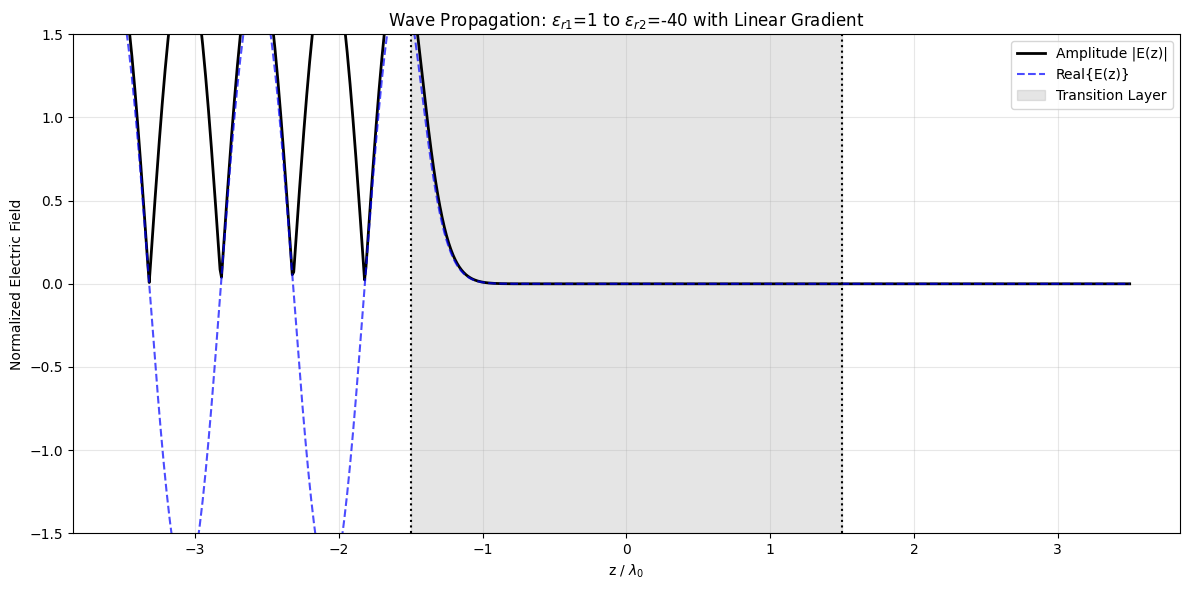

In [9]:
lambda0 = 1.0
d = 3 * lambda0  

# 测试用例：光从正介电常数区域隧穿入负介电常数区域 (或反之)
eps1 = 1   # 区域 1: 折射率为 1.5 的电介质
eps2 = -40   # 区域 2: 负介电常数材料 (如等离子体或金属)

def eps_linear(z):
    # 线性过渡
    return eps1 + (eps2 - eps1) * (z + d/2) / d

t, r, z_arr, E_arr, (z1, z2) = solve_helmholtz_piecewise(
    eps_linear, d, eps1, eps2, lambda0, L_ext_factor=2.0)
    
print(f"透射系数 t : {t:.4e}")
print(f"反射系数 r : {r:.4e}")
print(f"能量守恒检查 (|r|^2 + Re(k2/k1)|t|^2) : " 
        f"{np.abs(r)**2 + np.real(get_k(eps2, 2*np.pi)/get_k(eps1, 2*np.pi)) * np.abs(t)**2:.6f}")

# ================= 绘图 =================
plt.figure(figsize=(12, 6))

# 绘制振幅和实部
plt.plot(z_arr, np.abs(E_arr), 'k-', lw=2, label='Amplitude |E(z)|')
plt.plot(z_arr, np.real(E_arr), 'b--', alpha=0.7, label='Real{E(z)}')

# 标记过渡层区域
plt.axvspan(z1, z2, color='gray', alpha=0.2, label='Transition Layer')
plt.axvline(z1, color='k', linestyle=':')
plt.axvline(z2, color='k', linestyle=':')
plt.ylim(-1.5, 1.5)
plt.title(r'Wave Propagation: $\epsilon_{r1}$=' + f'{eps1}' + r' to $\epsilon_{r2}$=' + f'{eps2}' + r' with Linear Gradient')
plt.xlabel('z / $\lambda_0$')
plt.ylabel('Normalized Electric Field')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()